# Spectral Analysis with MNE

This notebook demonstrates the MNE-based spectral analysis functions in `pygc.spectral_analysis`:

1. **Fourier cross-spectrum** — fast, stationary signals
2. **Morlet wavelet transform** — time-frequency representation
3. **Welch cross-spectrum** — trial-averaged PSD / CSD
4. **Gabor coherence** — smoothed coherence from Gabor transform
5. **Granger Causality** from the Welch cross-spectrum

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pygc.spectral_analysis import (
    compute_freq, csd_fourier,
    morlet_transform, morlet_csd,
    welch_spectrum,
    wavelet_transform,
    gabor_transform, gabor_spectrum, gabor_coherence,
)
from pygc.ar_model import ar_model_dhamala

plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

## 1. Synthetic Signal

We generate two coupled signals: a sine at 30 Hz, and a sine at 30 Hz plus a sine at 10 Hz.

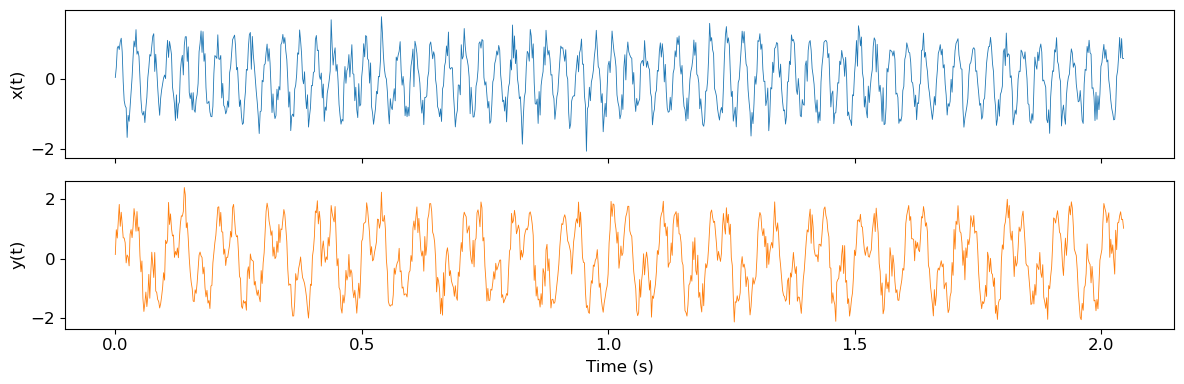

In [2]:
Fs  = 500.0   # Hz
N   = 1024    # samples
t   = np.arange(N) / Fs

rng = np.random.default_rng(0)

x = np.sin(2 * np.pi * 30 * t) + 0.3 * rng.standard_normal(N)
y = np.sin(2 * np.pi * 30 * t) + np.sin(2 * np.pi * 10 * t) + 0.3 * rng.standard_normal(N)

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(t, x, lw=0.6)
axes[0].set_ylabel('x(t)')
axes[1].plot(t, y, lw=0.6, color='C1')
axes[1].set_ylabel('y(t)')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()

## 2. Fourier Cross-Spectrum

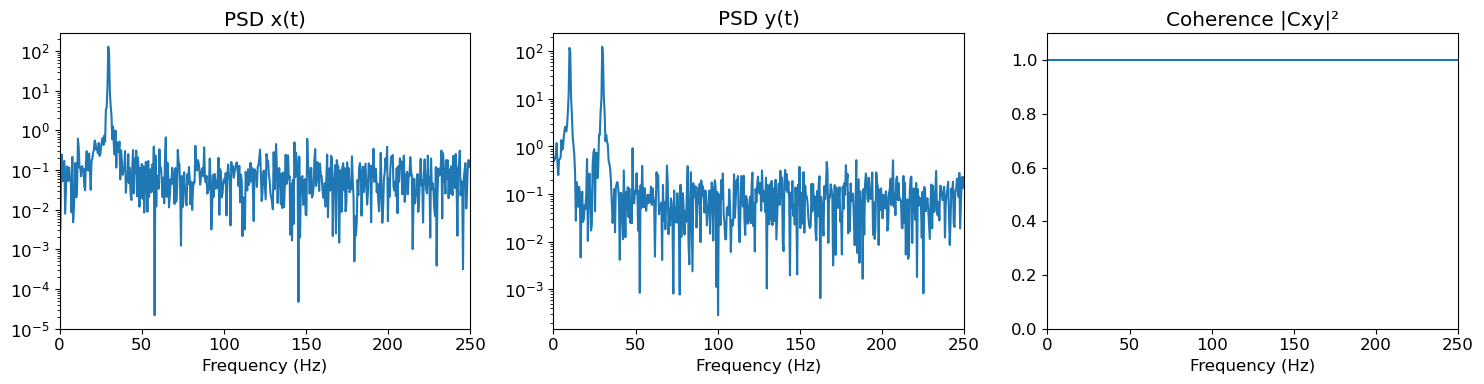

In [3]:
freq = compute_freq(N, Fs)

Pxx = csd_fourier(x, f=freq, Fs=Fs)          # auto-spectrum
Pyy = csd_fourier(y, f=freq, Fs=Fs)
Pxy = csd_fourier(x, Y=y, f=freq, Fs=Fs)     # cross-spectrum

coherence = np.abs(Pxy)**2 / (Pxx.real * Pyy.real)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].semilogy(freq, Pxx.real)
axes[0].set_title('PSD x(t)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_xlim([0, Fs/2])

axes[1].semilogy(freq, Pyy.real)
axes[1].set_title('PSD y(t)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_xlim([0, Fs/2])

axes[2].plot(freq, coherence)
axes[2].set_title('Coherence |Cxy|²')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_xlim([0, Fs/2])
axes[2].set_ylim([0, 1.1])

plt.tight_layout()

## 3. Morlet Wavelet Transform (MNE)

`morlet_transform` uses `mne.time_frequency.tfr_array_morlet` internally.

Wavelet transform shape (time x freq): (1024, 35)


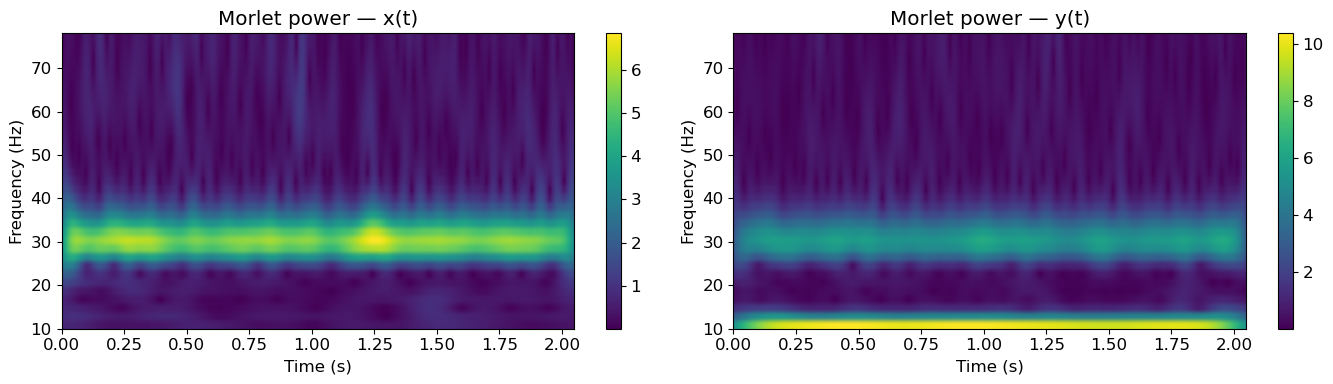

In [4]:
freqs_wav = np.arange(10, 80, 2, dtype=float)

Wx = morlet_transform(x, freqs_wav, Fs=Fs, n_cycles=7.0)
Wy = morlet_transform(y, freqs_wav, Fs=Fs, n_cycles=7.0)

print('Wavelet transform shape (time x freq):', Wx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, W, label in zip(axes, [Wx, Wy], ['x(t)', 'y(t)']):
    im = ax.imshow(np.abs(W).T, aspect='auto', origin='lower',
                   extent=[0, N/Fs, freqs_wav[0], freqs_wav[-1]])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'Morlet power — {label}')
    plt.colorbar(im, ax=ax)
plt.tight_layout()

## 4. Welch Cross-Spectrum (trial-averaged)

`welch_spectrum` computes the cross-spectral matrix averaged across trials using `scipy.signal.csd`.

Data shape (trials, channels, samples): (10, 2, 1024)
Welch spectral matrix shape: (2, 2, 129)


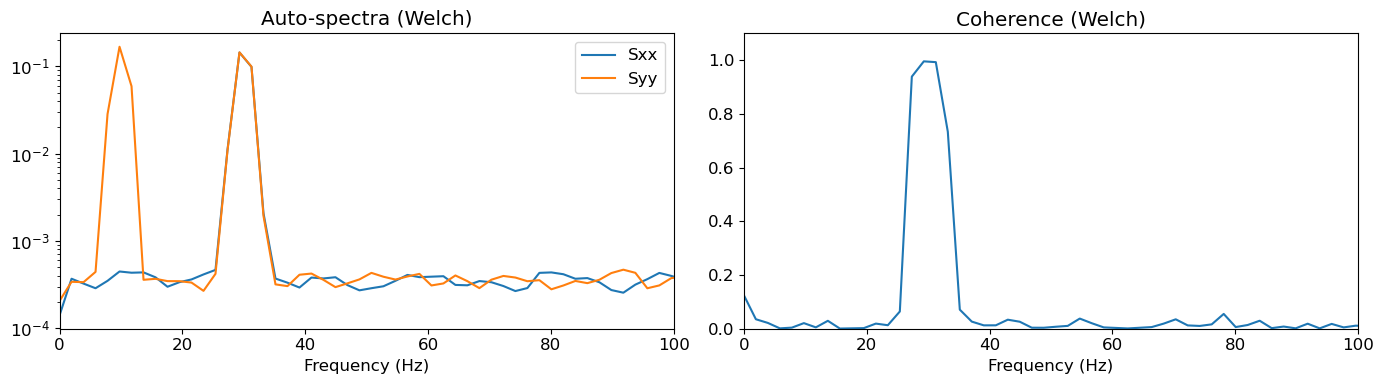

In [5]:
# Stack into (trials, channels, timepoints) format
np.random.seed(1)
Trials = 10
data = np.stack([
    np.stack([
        np.sin(2 * np.pi * 30 * t) + 0.3 * np.random.randn(N),
        np.sin(2 * np.pi * 30 * t) + np.sin(2 * np.pi * 10 * t) + 0.3 * np.random.randn(N),
    ], axis=0)
    for _ in range(Trials)
], axis=0)  # shape: (Trials, 2, N)

print('Data shape (trials, channels, samples):', data.shape)

S_welch = welch_spectrum(data=data, fs=Fs, scaling='density')
print('Welch spectral matrix shape:', S_welch.shape)

n_freq_welch = S_welch.shape[-1]
f_welch = np.linspace(0, Fs / 2, n_freq_welch)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(f_welch, S_welch[0, 0, :].real, label='Sxx')
axes[0].semilogy(f_welch, S_welch[1, 1, :].real, label='Syy')
axes[0].set_title('Auto-spectra (Welch)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].legend()
axes[0].set_xlim([0, 100])

coh_welch = np.abs(S_welch[0, 1, :])**2 / (S_welch[0, 0, :].real * S_welch[1, 1, :].real)
axes[1].plot(f_welch, coh_welch.real)
axes[1].set_title('Coherence (Welch)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylim([0, 1.1])
axes[1].set_xlim([0, 100])
plt.tight_layout()

## 5. Gabor Coherence (time-frequency)

Gabor coherence shape (freq x time): (38, 1024)


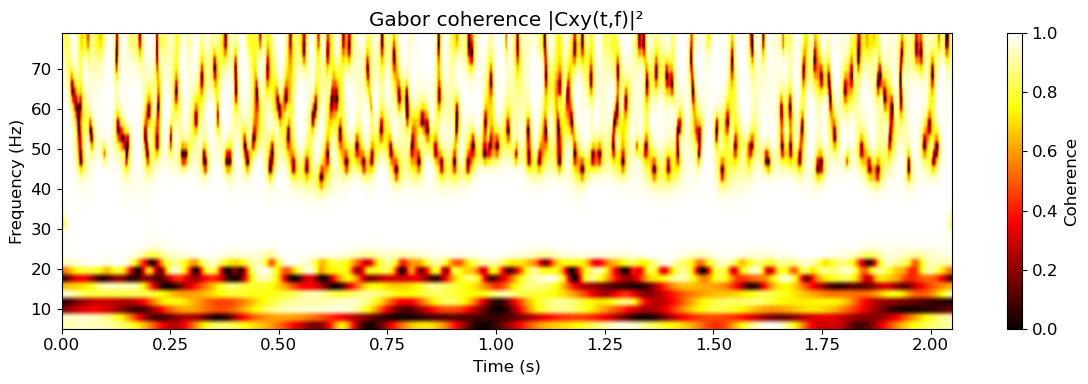

In [6]:
freqs_gab = np.arange(5, 80, 2, dtype=float)

coh_gab = gabor_coherence(signal1=x, signal2=y, fs=Fs,
                           freqs=freqs_gab, win_time=5, win_freq=3, n_cycles=6.0)

print('Gabor coherence shape (freq x time):', coh_gab.shape)

plt.figure(figsize=(12, 4))
plt.imshow(np.abs(coh_gab).real, aspect='auto', origin='lower',
           extent=[0, N/Fs, freqs_gab[0], freqs_gab[-1]],
           vmin=0, vmax=1, cmap='hot')
plt.colorbar(label='Coherence')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Gabor coherence |Cxy(t,f)|²')
plt.tight_layout()

## 6. Non-Parametric GC from Welch Spectrum

We use the Welch cross-spectrum from the Dhamala AR model and apply Wilson factorization.

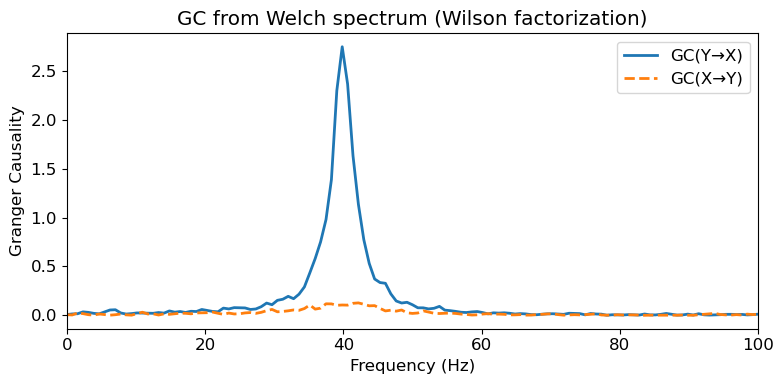

In [7]:
from pygc.ar_model import ar_model_dhamala
from pygc.granger import granger_causality

np.random.seed(0)
cov = np.eye(2) * 0.5
Z = ar_model_dhamala(N=2000, Trials=20, Fs=200.0, C=0.3,
                     t_start=0, t_stop=None, cov=cov)

# Build (trials, channels, time) array for welch_spectrum
data_ar = Z.transpose(1, 0, 2)  # (Trials, 2, N)

S_w = welch_spectrum(data=data_ar, fs=200.0, scaling='density')
n_f = S_w.shape[-1]
freq_w = np.linspace(0, 100, n_f)

Ix2y_w, Iy2x_w, _ = granger_causality(S_w, freq_w, 200.0, Niterations=200, verbose=False)

plt.figure(figsize=(8, 4))
plt.plot(freq_w, Ix2y_w, label='GC(Y→X)', lw=2)
plt.plot(freq_w, Iy2x_w, label='GC(X→Y)', lw=2, linestyle='--')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Granger Causality')
plt.title('GC from Welch spectrum (Wilson factorization)')
plt.legend()
plt.xlim([0, 100])
plt.tight_layout()